In [2]:
x = df[['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size', 'Garage_Size','Neighborhood_Quality']]
y = df['House_Price']

#Seperate into Train, Val and Test
y_train = np.array(y[:800])
y_val = np.array(y[800:900])
y_test = np.array(y[900:])

x_train = np.array(x[:800])
x_val= np.array(x[800:900])
x_test = np.array(x[900:])

#Compute Z-Score Vars
x_traind = x_train.std(axis=0, keepdims=True)
x_trainm = x_train.mean(axis=0, keepdims=True)
y_trainm = y_train.mean()
y_traind = y_train.std()

#Normalize targets and inputs for every split using Z-score vars.
y_train = (y_train - y_trainm)/y_traind
y_val = (y_val - y_trainm)/y_traind
y_test = (y_test - y_trainm)/y_traind 

x_train = (x_train - x_trainm)/x_traind
x_val = (x_val - x_trainm)/x_traind
x_test = (x_test - x_trainm)/x_traind


In [3]:
#Use a rng to initialize weights and then set bias to zero
rng = np.random.default_rng()
w = rng.normal(loc = 0.0, scale = 0.01, size = 7)
b = 0.01 #Bias should be small but not 0 so it gets updated

In [4]:
def backprop(x, y, yi, lr, w, b):
    N = x.shape[0]
    dw = (1/N) * np.dot(x.T, (yi - y))
    db = (1/N) * np.sum(yi - y) #Make sure to use np otherwise element wise won't work
    w = w - (dw * lr)
    b = b - (db * lr)
    return w, b

In [5]:
def train(w, b, epochs, lr, decay):
    #Should probably be saving these things to like a file or something as opposed to lists 
    #Can assign empty lists this way also. Looks way cleaner:
    lt, lv, ltm, ltv, lrl = [], [], [], [], []
    wl, bl = [], []
    
    for i in range(epochs):
        #Compute outputs (Can use dot product to sum and multiply at the same time)
        yi_train = np.dot(x_train, w) + b
        yi_val = np.dot(x_val, w) + b
        
        #Get losses
        N_train = len(y_train)  # 800
        N_val = len(y_val)
        
        loss_t = np.mean((yi_train - y_train) ** 2)
        loss_v = np.mean((yi_val - y_val) ** 2)
        loss_tm = np.mean(np.abs(yi_train - y_train))
        loss_vm = np.mean(np.abs(yi_val - y_val))
        
        #Store losses
        lt.append(loss_t)
        lv.append(loss_v)
        ltm.append(loss_tm)
        ltv.append(loss_vm)
        
        #Gradient Descent through and scale learning rate 
        wl.append(w)
        bl.append(b)
        w, b = backprop(x_train, y_train, yi_train, lr, w, b)
        lr *= decay #Learning rate scaling
        lrl.append(lr)
        #print("Epoch " + str((i+1)) + " completed the loss is: " + str(loss_t) + ". The val loss was " + str(loss_v) + ".")
    return wl, bl, lt, lv, ltm, ltv, lrl 

In [8]:
def graph(epochs, lt, lv, ltm, ltv, wl, bl, lr):
    epochs = np.arange(1, epochs + 1, dtype = float) #np has an arrange function that turns ranges into arrays specifically
    
    plt.plot(epochs, lt , '-r', label = 'Training Loss')
    plt.plot(epochs, lv, '-b', label = 'Validation Loss')
    plt.plot(epochs, ltm, '-k', label='Train MAE')
    plt.plot(epochs, ltv, '-g', label='Val MAE')
        
    

    plt.xlabel('Epochs') 
    plt.legend()    
    plt.show()

    plt.plot(epochs, bl, '--b',  label = 'Biases')
    plt.plot(epochs, lr, '--r', label = 'Learning Rate')
    
    plt.xlabel('Epochs')
    plt.legend()
    plt.show()

    plt.plot(epochs, np.array(wl))

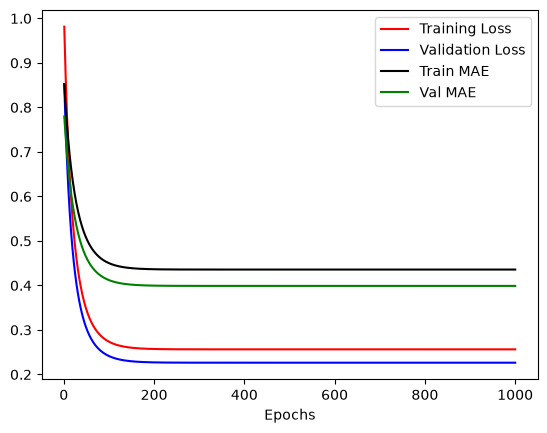

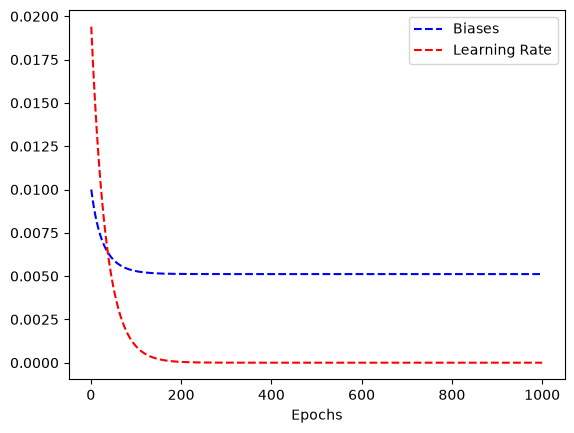

/var/folders/p5/dw8jzbt1551dftc2dnp5z9xc0000gn/T/ipykernel_42191/503036933.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


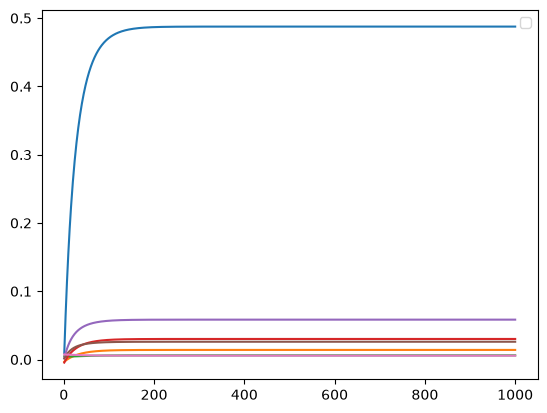

In [7]:
#Now that everything has been completed run the functions and train the model

#Set training hyper parameters
epochs = 1000
lr = 0.02
decay = 0.97

#Run training loop:
wl, bl, lt, lv, ltm, ltv, lrl = train(w, b, epochs, lr, decay)
graph(epochs, lt, lv, ltm, ltv, wl, bl, lrl)